目視：緩いトレンド、季節性ありそう、ほぼ正規分布

ADF,KPSSで非定常確認、差分をとってもう一度検定
定常確認　d=1

ACF/PACF ラグ１２でピーク　s=12 p=1 q=1 モデル作成

データ分割して学習、予測して実績と比較、後半に若干のずれがあるが形は一致
他データがあれば外部変数追加

SARIMAはトレンド除去して計算するため
トレンド、季節性の複雑さも加味してモデル作成するならProphet
精度目的ならLightGBMなど検討

array([[<Axes: title={'center': 'value'}>]], dtype=object)

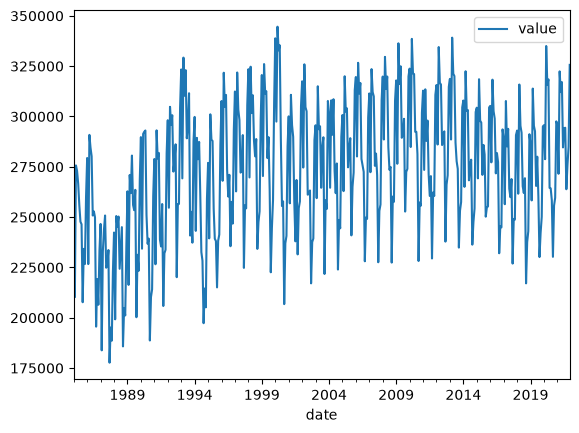

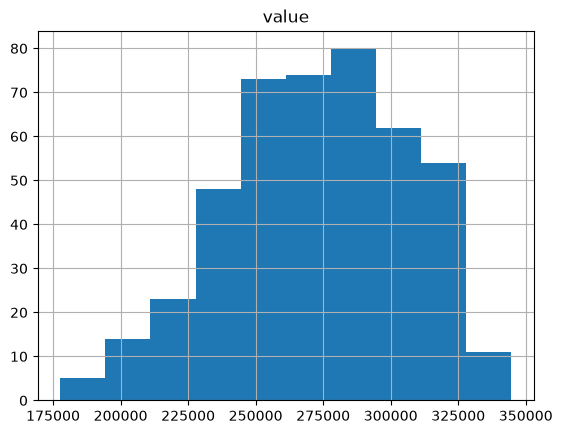

In [69]:


df = pd.read_csv('data/Processing volume for dairy products.csv')
df=df.dropna()\
     .replace(',','',regex=True)\
     .astype(int)\
     .set_index('year')

df_s=df.reset_index()    #インデックスをカラムへ
cols=[c for c in df.columns if c !='total']  #集計以外のカラム名を取得

#year列だけ残して、取得したカラム名をデータとしたmonthカラムを作る
df_f=df_s.melt(id_vars='year',var_name='month',value_vars=cols).astype('int')   

dfl=df_f.sort_values(['year','month'])  #昇順に並び替え
dfl['date']=pd.to_datetime(dfl[['year','month']].assign(day=1))  #１日付のデータへ変換

df_f=dfl.set_index('date').drop(columns=['year','month'])   #値のみ
df_f.plot()
df_f.hist()


In [79]:
from statsmodels.tsa.stattools import adfuller,kpss

#定常か非定常か
adf = adfuller(df_f['value'])
print('=== ADF ===')
print(f'統計量: {adf[0]:.4f}')
print(f'p値:    {adf[1]:.4f}')

kps = kpss(df_f['value'])
print('\n=== KPSS ===')
print(f'統計量: {kps[0]:.4f}')
print(f'p値:    {kps[1]:.4f}')


=== ADF ===
統計量: -2.5858
p値:    0.0960

=== KPSS ===
統計量: 1.8901
p値:    0.0100


C:\Users\owner\AppData\Local\Temp\ipykernel_13900\2166762185.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kps = kpss(df_f['value'])


In [82]:
#
df_diff = df_f['value'].diff().dropna()

adf2=adfuller(df_diff)
print('=== ADF ===')
print(f'統計量: {adf2[0]:.4f}')
print(f'p値:    {adf2[1]:.4f}')

kps2 = kpss(df_diff)
print('\n=== KPSS ===')
print(f'統計量: {kps2[0]:.4f}')
print(f'p値:    {kps2[1]:.4f}')



=== ADF ===
統計量: -6.0082
p値:    0.0000

=== KPSS ===
統計量: 0.0171
p値:    0.1000


C:\Users\owner\AppData\Local\Temp\ipykernel_13900\2531284830.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kps2 = kpss(df_diff)


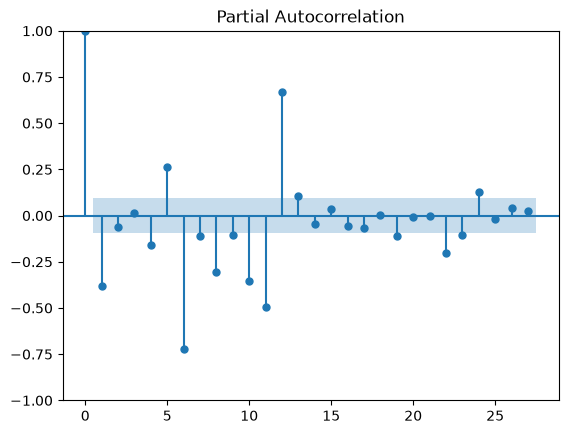

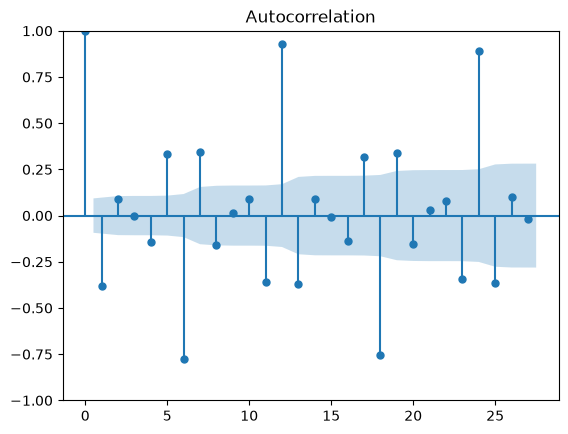

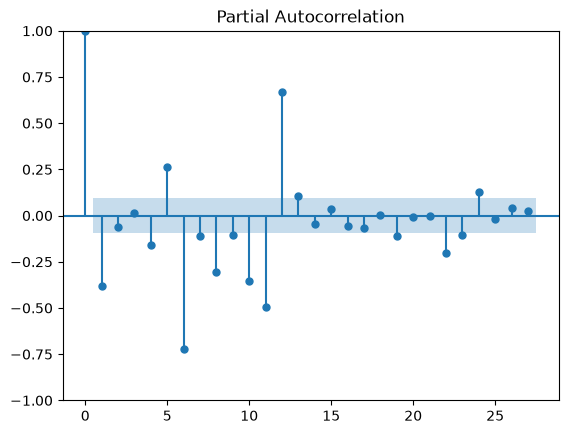

In [83]:
#ACF/PACF
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

plot_acf(df_diff)
plot_pacf(df_diff)

In [93]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

df_train = df_f[:'2020']
df_test = df_f['2021':]

model=SARIMAX(df_train['value'],order=(1,1,1),seasonal_order=(1,1,1,12))
result=model.fit()
print(result.summary())

# order=(p,d,q)
# seasonal_order=(P,D,Q,s)

c:\Users\owner\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\owner\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                              value   No. Observations:                  432
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -4418.545
Date:                            Sat, 27 Jun 2026   AIC                           8847.090
Time:                                    01:44:52   BIC                           8867.279
Sample:                                01-01-1985   HQIC                          8855.070
                                     - 12-01-2020                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3651      0.370      0.986      0.324      -0.360       1.091
ma.L1         -0.4523      0.369   

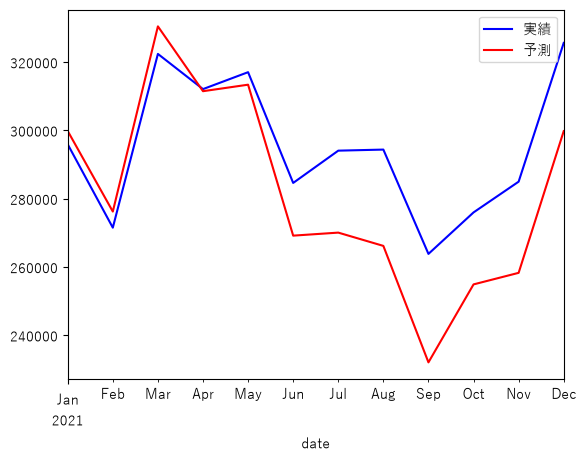

In [ ]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'YU Gothic'

r=result.forecast(steps=12)

ax=df_test['value'].plot(label='実績',color='blue')
r.plot(ax=ax,label='予測',color='red')
ax.legend()
